In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayeshasiddiqa123/student-perfirmance/StudentPerformanceFactors.csv
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__results__.html
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__resultx__.html
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__notebook__.ipynb
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__output__.json
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/custom.css
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__results___files/__results___72_0.png
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__results___files/__results___67_0.png
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__results___files/__results___39_0.png
/kaggle/input/notebooks/bhartiprasad17/student-academic-performance-analysis/__results___files/__

In [2]:
import pandas as pd
df= pd.read_csv('/kaggle/input/datasets/ayeshasiddiqa123/student-perfirmance/StudentPerformanceFactors.csv')
print(df.head())
#information about the dataset
print(df.info())
print(df.describe())

#defining the target variable

#exp 2
#applying filter
high_scorers = df[df['Exam_Score'] > 80]
print(high_scorers.head())

#identifying cols
df.columns = df.columns.str.strip()
print(df.columns)
#checking rows and shapes
print("Rows, Columns:", df.shape)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

#check missing values
df.isnull().sum()

#total missing values
df.isnull().sum().sum()
#percentage of missing values
(df.isnull().sum() / len(df)) * 100

#it is a CSV file so data is strucutured 
#unstructured dataset consists of images,audio,videos
#identify target variables
#variables with strongest correlation is targetvar
df.corr(numeric_only=True)['Exam_Score'].sort_values(ascending=False)

#if it is classification or regression
df['Exam_Score'].dtype
df['Exam_Score'].nunique()


   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

45

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

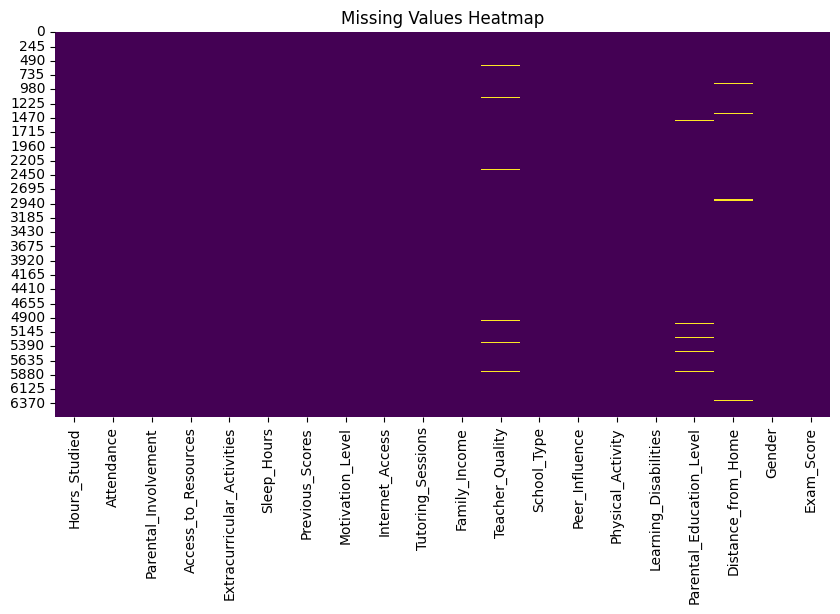

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
#generating heatmap for missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


In [5]:
#separating input features and target
x= df.drop(columns=['Exam_Score'])
y= df['Exam_Score']
print(x.head())
print(y.head())

#preporcessing of data
#identifying which features affect student academic performance
#can  not use correlation analysis because it works only numeric data

numeric_cols= df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols= df.select_dtypes(include=['object']).columns
print("Numeric colummns:\n", numeric_cols)
print("\nCategorical columns:\n", categorical_cols)

#using correlation to convert into numeric values
numeric_corr= df[numeric_cols].corr()
numeric_corr['Exam_Score'].sort_values(ascending=False)

#correaltion requires numbers 
#uses hot-encoding 
df_encoded= pd.get_dummies(df,drop_first=True)
df_encoded.head()

#performing correlation on full dataset
# correlation

corr_full = df_encoded.corr()


#correlation
corr_full = df_encoded.corr(method='pearson')

exam_corr = corr_full['Exam_Score'].sort_values(ascending=False)
print(exam_corr)



   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

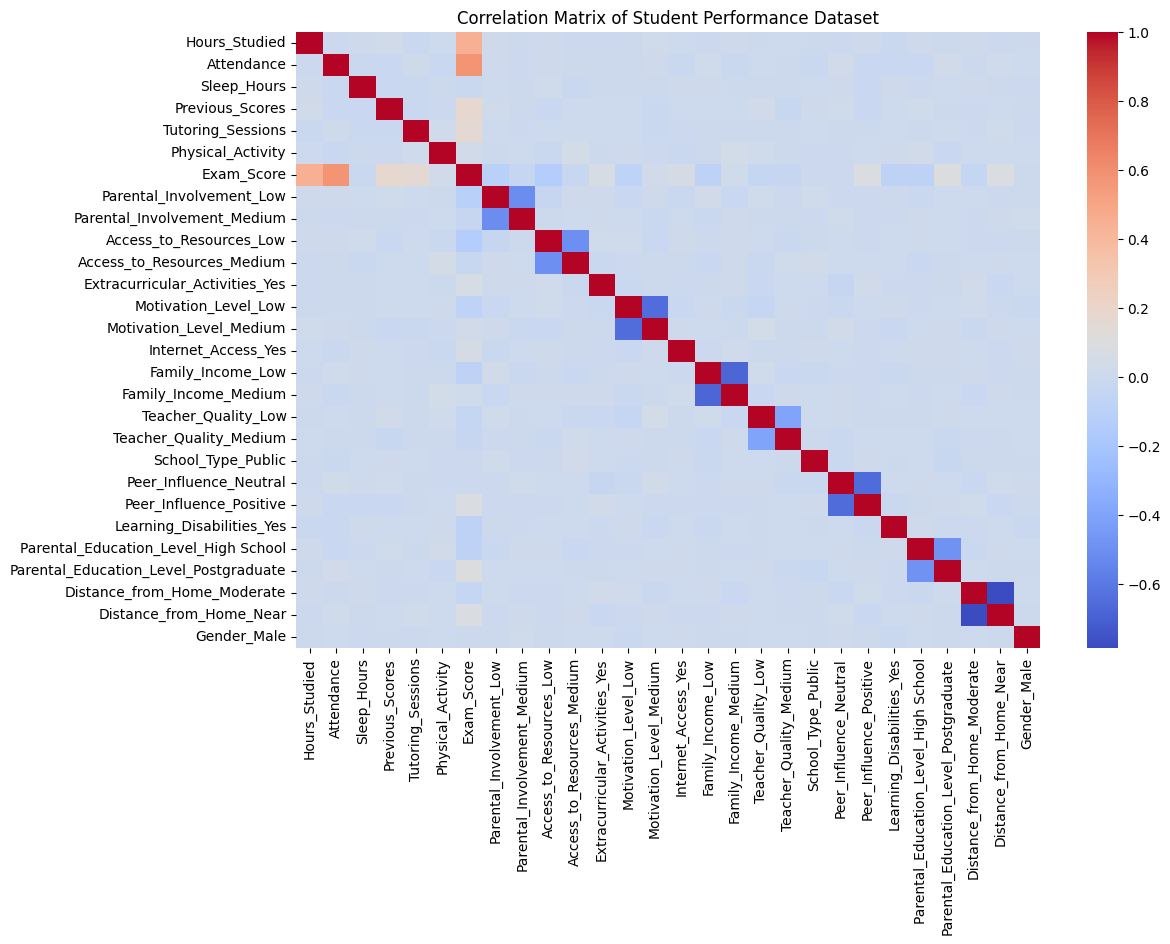

In [6]:
#generating heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_full, cmap='coolwarm')
plt.title("Correlation Matrix of Student Performance Dataset")
plt.show()
### Conclusion
#- Correlation analysis confirms that multiple factors influence student academic performance.
#- Both numerical and categorical features contribute to exam score prediction.
#- The dataset is suitable for supervised machine learning models.

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)
corr_full = df_encoded.corr(method='pearson')
exam_corr = corr_full['Exam_Score'].sort_values(ascending=False)
print(exam_corr)

#feature selection
important_features = exam_corr[abs(exam_corr) > 0.2]
print(important_features)

#separate x and y
X=df_encoded[important_features.index.drop('Exam_Score')]
y=df_encoded['Exam_Score']
print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#evaluating model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
print("MAE:", mean_absolute_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))



Exam_Score                               1.000000
Attendance                               0.581072
Hours_Studied                            0.445455
Previous_Scores                          0.175079
Tutoring_Sessions                        0.156525
Parental_Education_Level_Postgraduate    0.093764
Distance_from_Home_Near                  0.084870
Peer_Influence_Positive                  0.081217
Extracurricular_Activities_Yes           0.064382
Internet_Access_Yes                      0.051475
Physical_Activity                        0.027824
Motivation_Level_Medium                  0.024771
Family_Income_Medium                     0.020995
Gender_Male                             -0.002032
Peer_Influence_Neutral                  -0.007795
School_Type_Public                      -0.008844
Sleep_Hours                             -0.017022
Access_to_Resources_Medium              -0.026158
Parental_Involvement_Medium             -0.035978
Teacher_Quality_Medium                  -0.039294


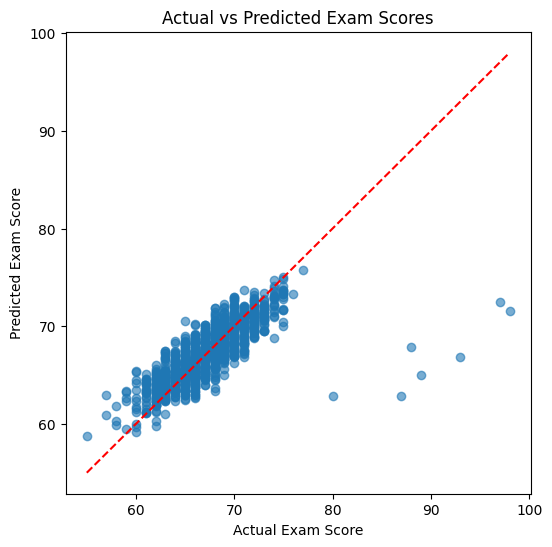

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.show()

In [9]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DT RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("DT R2:", r2_score(y_test, y_pred_dt))

import pandas as pd

#importance of featured parameters
#“The coefficient of Attendance is higher than Hours_Studied, indicating that attendance has a stronger positive impact on exam scores compared to study hours.”
feature_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

#converting into % for decision making
#Attendance contributes approximately 60.7% and Hours_Studied contributes about 39.3% to the model’s decision-making process
feature_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
) * 100

print(feature_importance.sort_values(ascending=False))

DT RMSE: 2.7326906504752833
DT R2: 0.4716972123468247
Attendance       0.60759
Hours_Studied    0.39241
dtype: float64
Attendance       60.758988
Hours_Studied    39.241012
dtype: float64
